In [1]:
import numpy as np

def func(x, y):
    return x*(1-x)*np.cos(4*np.pi*x)*np.sin(4*np.pi*y**2)**2

grid_x, grid_y = np.meshgrid(np.linspace(0, 1, 100), np.linspace(0, 1, 200), indexing='ij')

In [17]:
rng = np.random.default_rng()
points = rng.random((100, 2))
values = func(points[:, 0], points[:, 1])

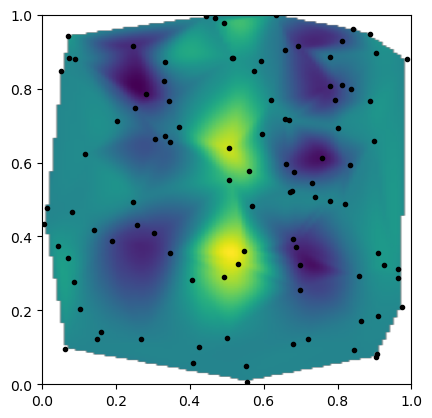

In [18]:
from scipy.interpolate import griddata
import matplotlib.pyplot as plt

grid_z0 = griddata(points, values, (grid_x, grid_y), method='nearest')
grid_z1 = griddata(points, values, (grid_x, grid_y), method='linear')
grid_z2 = griddata(points, values, (grid_x, grid_y), method='cubic')

plt.plot(points[:, 0], points[:, 1], '.k')
plt.imshow(grid_z2.T, extent=(0, 1, 0, 1), origin='lower')

In [22]:
from scipy.interpolate import RBFInterpolator, InterpolatedUnivariateSpline

In [19]:
x = np.linspace(0, 10, 9).reshape(-1, 1)
y = np.sin(x)
xi = np.linspace(0, 10, 101).reshape(-1, 1)

In [23]:
ius = InterpolatedUnivariateSpline(x, y)
yi = ius(xi)

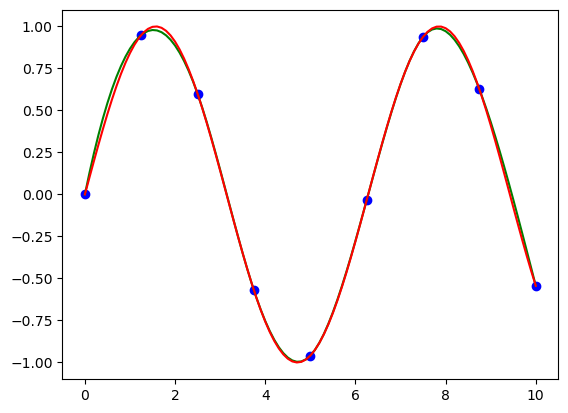

In [29]:
plt.plot(x, y, 'bo')
plt.plot(xi, yi, 'g')
plt.plot(xi, np.sin(xi), 'r')


In [25]:
rbf = RBFInterpolator(x, y)
fi = rbf(xi)

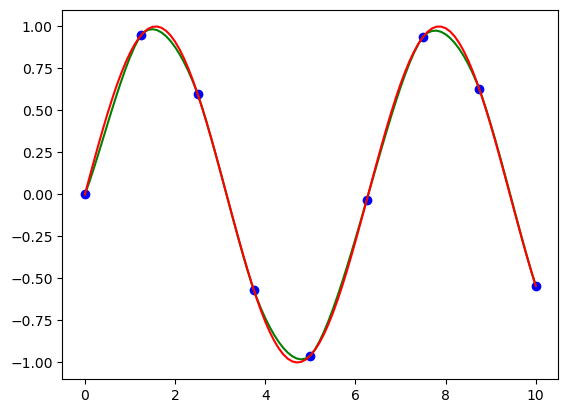

In [27]:
plt.plot(x, y, 'bo')
plt.plot(xi, fi, 'g')
plt.plot(xi, np.sin(xi), 'r')
